In [55]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import seaborn as sns

In [99]:
data = pd.DataFrame(columns = ['sched', 'hyper', 'n_load', 'sim_time', 'mem_size'])
data.loc[len(data)] = ['graph_test', 0, 23090, 48.299, 80]
data.loc[len(data)] = ['graph_test', 1, 23123, 53.280, 80]
data.loc[len(data)] = ['graph_test', 2, 17337, 9.942, 80]
data.loc[len(data)] = ['graph_test', 3, 16459, 11.030, 80]
data.loc[len(data)] = ['graph_test', 4, 18455, 11.510, 80]
data.loc[len(data)] = ['new_v2', 1, 17366, 10.526, 80]
data.loc[len(data)] = ['new_v2', 2, 18079, 12.269, 80]
data.loc[len(data)] = ['new_v2', 3, 18323, 12.782, 80]
data.loc[len(data)] = ['new_v2', 4, 18583, 13.323, 80]
data.loc[len(data)] = ['new_v2', 5, 18585, 13.294, 80]
data.loc[len(data)] = ['new_v2', 6, 18560, 13.221, 80]
data.loc[len(data)] = ['new_v2', 7, 18788, 13.754, 80]

data.loc[len(data)] = ['graph_test', 0, 23935, 53.846, 60]
data.loc[len(data)] = ['graph_test', 1, 24909, 58.998, 60]
data.loc[len(data)] = ['graph_test', 2, 19039, 13.580, 60]
data.loc[len(data)] = ['graph_test', 3, 17472, 13.644, 60]
data.loc[len(data)] = ['graph_test', 4, 18471, 11.522, 60]
data.loc[len(data)] = ['new_v2', 1, 19132, 14.330, 60]
data.loc[len(data)] = ['new_v2', 2, 19563, 15.144, 60]
data.loc[len(data)] = ['new_v2', 3, 19709, 15.409, 60]
data.loc[len(data)] = ['new_v2', 4, 19875, 15.650, 60]
data.loc[len(data)] = ['new_v2', 5, 19864, 15.637, 60]
data.loc[len(data)] = ['new_v2', 6, 19819, 15.627, 60]
data.loc[len(data)] = ['new_v2', 7, 19942, 15.861, 60]

data.loc[len(data)] = ['graph_test', 0, 24691, 57.059, 40]
data.loc[len(data)] = ['graph_test', 1, 25398, 60.795, 40]
data.loc[len(data)] = ['graph_test', 2, 20640, 17.133, 40]
data.loc[len(data)] = ['graph_test', 3, 19182, 15.551, 40]
data.loc[len(data)] = ['graph_test', 4, 18483, 11.529, 40]
data.loc[len(data)] = ['new_v2', 1, 20816, 17.910, 40]
data.loc[len(data)] = ['new_v2', 2, 21011, 17.968, 40]
data.loc[len(data)] = ['new_v2', 3, 21083, 17.982, 40]
data.loc[len(data)] = ['new_v2', 4, 21136, 18.011, 40]
data.loc[len(data)] = ['new_v2', 5, 21115, 18.035, 40]
data.loc[len(data)] = ['new_v2', 6, 21083, 18.033, 40]
data.loc[len(data)] = ['new_v2', 7, 21134, 18.052, 40]

data.loc[len(data)] = ['graph_test', 0, 25637, 58.516, 20]
data.loc[len(data)] = ['graph_test', 1, 26519, 62.449, 20]
data.loc[len(data)] = ['graph_test', 2, 21897, 19.174, 20]
data.loc[len(data)] = ['graph_test', 3, 21690, 20.313, 20]
data.loc[len(data)] = ['graph_test', 4, 18494, 11.539, 20]
data.loc[len(data)] = ['new_v2', 1, 22115, 19.891, 20]
data.loc[len(data)] = ['new_v2', 2, 22262, 20.043, 20]
data.loc[len(data)] = ['new_v2', 3, 22282, 20.103, 20]
data.loc[len(data)] = ['new_v2', 4, 22322, 20.139, 20]
data.loc[len(data)] = ['new_v2', 5, 22320, 20.120, 20]
data.loc[len(data)] = ['new_v2', 6, 22298, 20.108, 20]
data.loc[len(data)] = ['new_v2', 7, 22339, 20.144, 20]

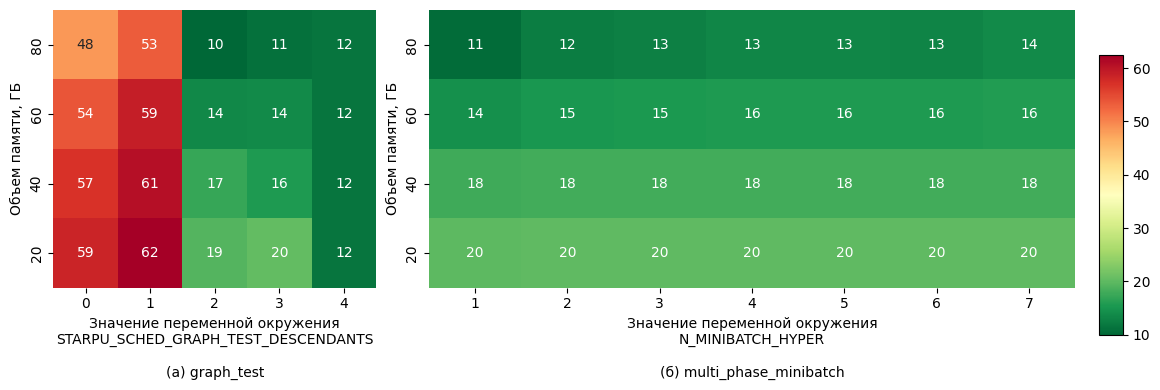

In [100]:
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2])

# Находим минимальное и максимальное значения 'sim_time' для всех данных
vmin = data['sim_time'].min()
vmax = data['sim_time'].max()

# Функция для создания heatmap с общей цветовой шкалой
def create_heatmap(data, ax, xlabel, ylabel, vmin, vmax):
    heatmap_data = data.pivot_table(values='sim_time', index='mem_size', columns='hyper')
    sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax, cbar=False, vmin=vmin, vmax=vmax, yticklabels=heatmap_data.index) # cbar=False для отключения отдельных шкал
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.invert_yaxis()

# Первый график (graph_test)
ax1 = fig.add_subplot(gs[0])
df = data.query('sched == "graph_test"')
create_heatmap(df, ax1, 'Значение переменной окружения\nSTARPU_SCHED_GRAPH_TEST_DESCENDANTS\n\n(а) graph_test', 'Объем памяти, ГБ', vmin, vmax)

# Второй график (new_v2)
ax2 = fig.add_subplot(gs[1])
df = data.query('sched == "new_v2"')
create_heatmap(df, ax2, 'Значение переменной окружения\nN_MINIBATCH_HYPER\n\n(б) multi_phase_minibatch', 'Объем памяти, ГБ', vmin, vmax)


plt.tight_layout()

# Добавление общей цветовой шкалы
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
#  Нормализация цветовой шкалы
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)


plt.show()

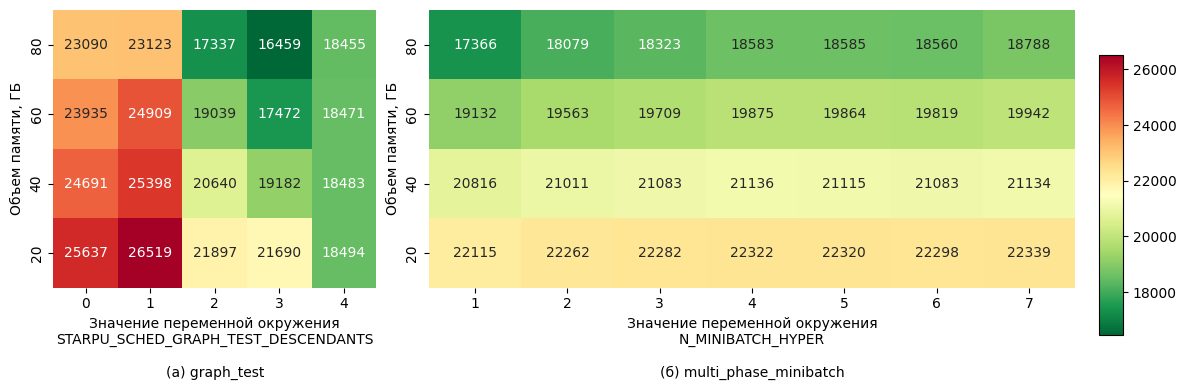

In [101]:
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2])

# Находим минимальное и максимальное значения 'n_load' для всех данных
vmin = data['n_load'].min()
vmax = data['n_load'].max()

# Функция для создания heatmap с общей цветовой шкалой
def create_heatmap(data, ax, xlabel, ylabel, vmin, vmax):
    heatmap_data = data.pivot_table(values='n_load', index='mem_size', columns='hyper')
    sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax, cbar=False, vmin=vmin, vmax=vmax, yticklabels=heatmap_data.index) # cbar=False для отключения отдельных шкал
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.invert_yaxis()

# Первый график (graph_test)
ax1 = fig.add_subplot(gs[0])
df = data.query('sched == "graph_test"')
create_heatmap(df, ax1, 'Значение переменной окружения\nSTARPU_SCHED_GRAPH_TEST_DESCENDANTS\n\n(а) graph_test', 'Объем памяти, ГБ', vmin, vmax)

# Второй график (new_v2)
ax2 = fig.add_subplot(gs[1])
df = data.query('sched == "new_v2"')
create_heatmap(df, ax2, 'Значение переменной окружения\nN_MINIBATCH_HYPER\n\n(б) multi_phase_minibatch', 'Объем памяти, ГБ', vmin, vmax)


plt.tight_layout()

# Добавление общей цветовой шкалы
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
#  Нормализация цветовой шкалы
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)


plt.show()

In [58]:
def addlabels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                '%d' % int(height),
                ha='center', va='bottom')

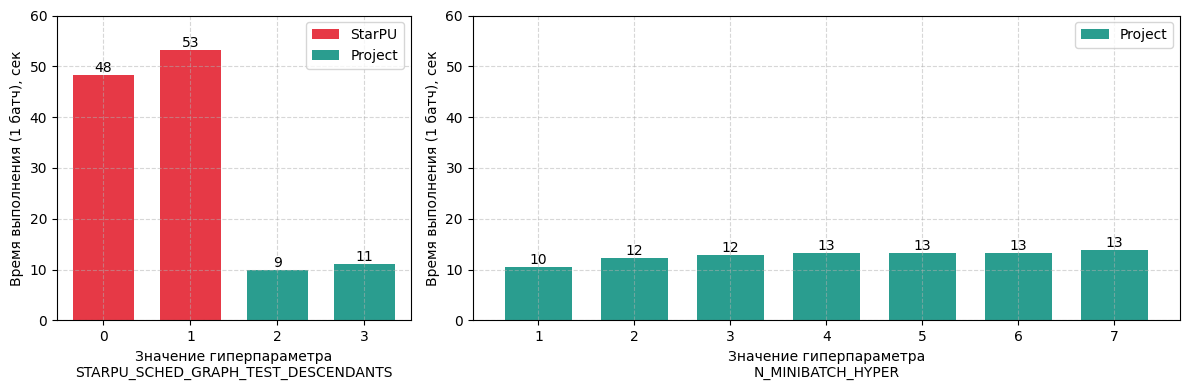

In [59]:
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2])

# Первый график (graph_test)
ax1 = fig.add_subplot(gs[0])

df = data.query('sched == "graph_test" & mem_size == 80')
df_starpu = df[df['hyper'] < 2]
df_project = df[df['hyper'] >= 2]

bar_width = 0.7 #  Фиксированная ширина столбцов

bars1 = ax1.bar(df_starpu['hyper'], df_starpu['sim_time'], width=bar_width, color='#E63946', label='StarPU')
bars2 = ax1.bar(df_project['hyper'], df_project['sim_time'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars1) #  Функция addlabels() должна быть определена где-то выше
addlabels(bars2)

ax1.set_xlabel('Значение гиперпараметра\nSTARPU_SCHED_GRAPH_TEST_DESCENDANTS')
ax1.set_ylabel('Время выполнения (1 батч), сек')
ax1.grid(linestyle='--', alpha=0.5)
ax1.set_xticks(np.arange(4))
ax1.set_ylim(0, 60)
ax1.legend()


# Второй график (new_v2)
ax2 = fig.add_subplot(gs[1])

df = data.query('sched == "new_v2" & mem_size == 80')
bars = ax2.bar(df['hyper'], df['sim_time'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars)

ax2.set_xlabel('Значение гиперпараметра\nN_MINIBATCH_HYPER')
ax2.set_ylabel('Время выполнения (1 батч), сек')
ax2.grid(linestyle='--', alpha=0.5)
ax2.set_xticks(np.arange(1, 8))
ax2.set_ylim(0, 60)
ax2.legend()


plt.tight_layout() #  Для лучшего расположения элементов
plt.show()

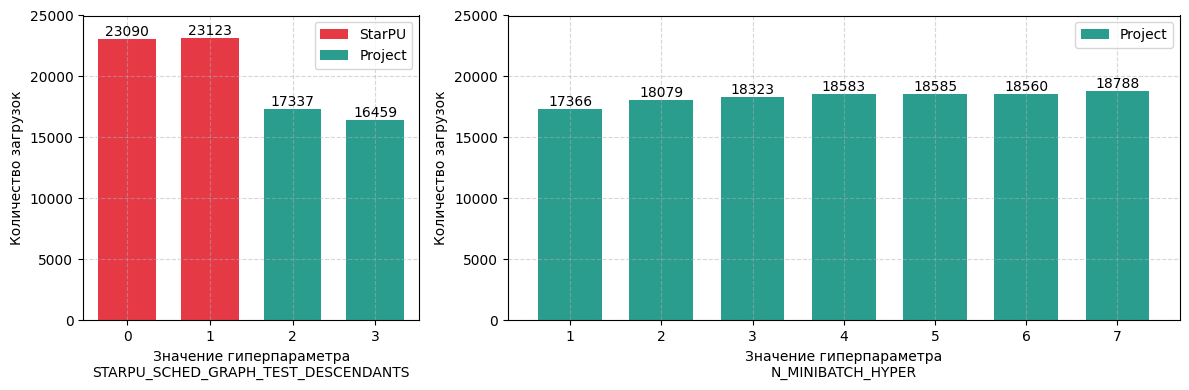

In [60]:
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 2])

# Первый график (graph_test)
ax1 = fig.add_subplot(gs[0])

df = data.query('sched=="graph_test" & mem_size == 80')
df_starpu = df[df['hyper'] < 2]
df_project = df[df['hyper'] >= 2]

bar_width = 0.7 #  Фиксированная ширина столбцов

bars1 = ax1.bar(df_starpu['hyper'], df_starpu['n_load'], width=bar_width, color='#E63946', label='StarPU')
bars2 = ax1.bar(df_project['hyper'], df_project['n_load'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars1) #  Функция addlabels() должна быть определена где-то выше
addlabels(bars2)

ax1.set_xlabel('Значение гиперпараметра\nSTARPU_SCHED_GRAPH_TEST_DESCENDANTS')
ax1.set_ylabel('Количество загрузок')
ax1.grid(linestyle='--', alpha=0.5)
ax1.set_xticks(np.arange(4))
ax1.set_ylim(0, 25000)
ax1.legend()


# Второй график (new_v2)
ax2 = fig.add_subplot(gs[1])

df = data.query('sched=="new_v2" & mem_size == 80')
bars = ax2.bar(df['hyper'], df['n_load'], width=bar_width, color='#2A9D8F', label='Project')

addlabels(bars)

ax2.set_xlabel('Значение гиперпараметра\nN_MINIBATCH_HYPER')
ax2.set_ylabel('Количество загрузок')
ax2.grid(linestyle='--', alpha=0.5)
ax2.set_xticks(np.arange(1, 8))
ax2.set_ylim(0, 25000)
ax2.legend()


plt.tight_layout() #  Для лучшего расположения элементов
plt.show()